In [1]:
%matplotlib inline

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import PIL.Image
from IPython.display import display, clear_output
import fastf1

# Optional: enable FastF1 cache to avoid re-downloading
fastf1.Cache.enable_cache('../.fastf1_cache')

In [4]:
from scripts.track_loader import load_track, plot_track   # the script provided

CIRCUIT  = 'Monza'   # try 'Monaco', 'Spa', 'Silverstone', …
YEAR     = 2023
SPACING  = 5.0       # meters between centerline points

print(f'Loading {CIRCUIT} {YEAR} …')
track_data = load_track(CIRCUIT, year=YEAR, spacing_m=SPACING)

print(f"  Circuit length : {track_data['circuit_length_m']:.0f} m")
print(f"  Centerline pts : {len(track_data['centerline'])}")
print(f"  Scale factor   : {track_data['scale']:.4f} m/native")

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loading Monza 2023 …


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['55', '1', '16', '63', '11', '23', '81', '44', '4', '14', '22', '40', '27', '77', '2', '24', '10', '31', '20', '18']


  Circuit length : 5766 m
  Centerline pts : 1153
  Scale factor   : 0.1001 m/native


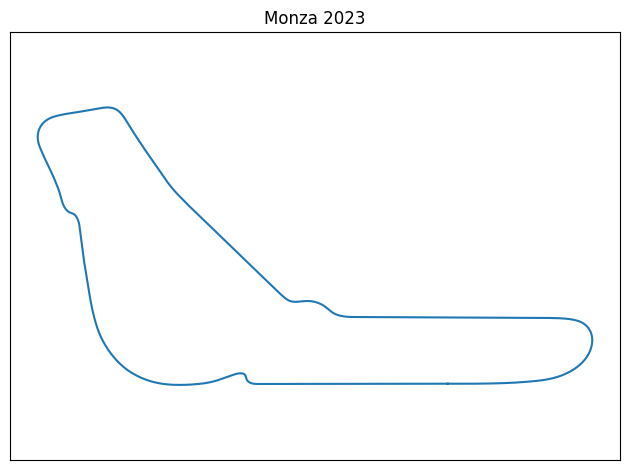

In [5]:
plot_track(track_data, title=f'{CIRCUIT} {YEAR}')

In [6]:
from env.track_env import TrackEnv   # the environment file

MAX_STEPS = 2000

env = TrackEnv(
    track_data  = track_data,
    max_steps   = MAX_STEPS,
    render_mode = 'rgb_array',
)

print('Observation space:', env.observation_space)
print('Action space     :', env.action_space)

Observation space: Box([  0.   -7.5 -90.  -90. ], [ 1.   7.5 90.  90. ], (4,), float32)
Action space     : Box(-1.0, 1.0, (2,), float32)


Initial obs : None
Info        : [-981.87603634 -127.0379296 ]
Frame shape : (708, 1315, 3)   dtype: uint8


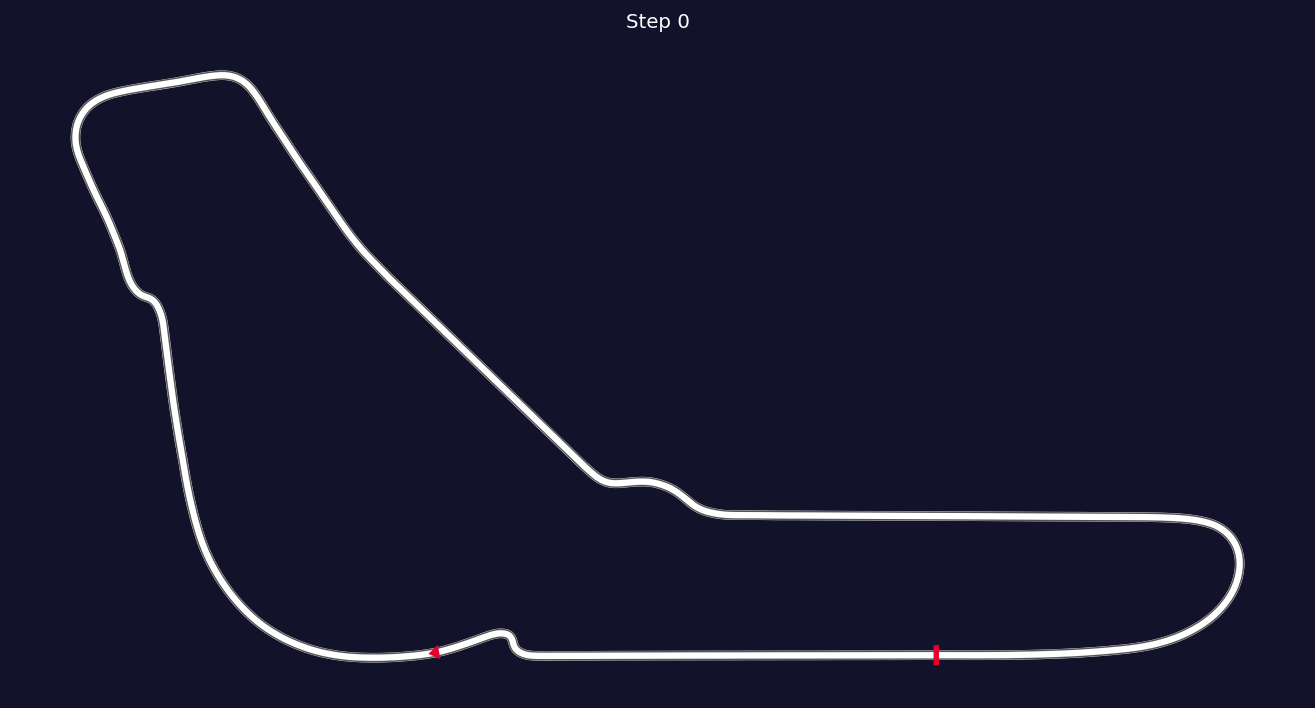

In [7]:
obs, info = env.reset(seed=42)
print('Initial obs :', obs)
print('Info        :', info)

frame = env.render()
print('Frame shape :', frame.shape, '  dtype:', frame.dtype)
display(PIL.Image.fromarray(frame))